In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops,hog
from skimage.filters import sobel
import pandas as pd
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import numpy as np
from sklearn.preprocessing import StandardScaler


In [6]:


df=pd.read_csv("csv/features.csv")

X = df.drop(columns=["label", "dataset"]).values 
y = df["label"].values
dataset_type = df["dataset"].values 


X_train = X[dataset_type == "Training"]
y_train = y[dataset_type == "Training"]
X_test = X[dataset_type == "Testing"]
y_test = y[dataset_type == "Testing"]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

model = xgb.XGBClassifier(
    objective="'multi:softmax'",
    n_estimators=100,           
    learning_rate=0.1,          
    max_depth=3,                
    subsample=0.8,               
    colsample_bytree=0.8,        
    random_state=42
)

model.fit(X_train, y_train)

# make Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9016018306636155

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       405
           1       0.90      0.78      0.84       300
           2       0.81      0.83      0.82       306
           3       0.92      0.97      0.95       300

    accuracy                           0.90      1311
   macro avg       0.90      0.89      0.89      1311
weighted avg       0.90      0.90      0.90      1311



In [18]:
from sklearn.model_selection import cross_val_score
train_score = cross_val_score(model, X_train, y_train, cv=5)
print(f"the training score of the model: {train_score}")


the training score of the model: [0.84514436 0.92825897 0.91243433 0.82924694 0.78283713]


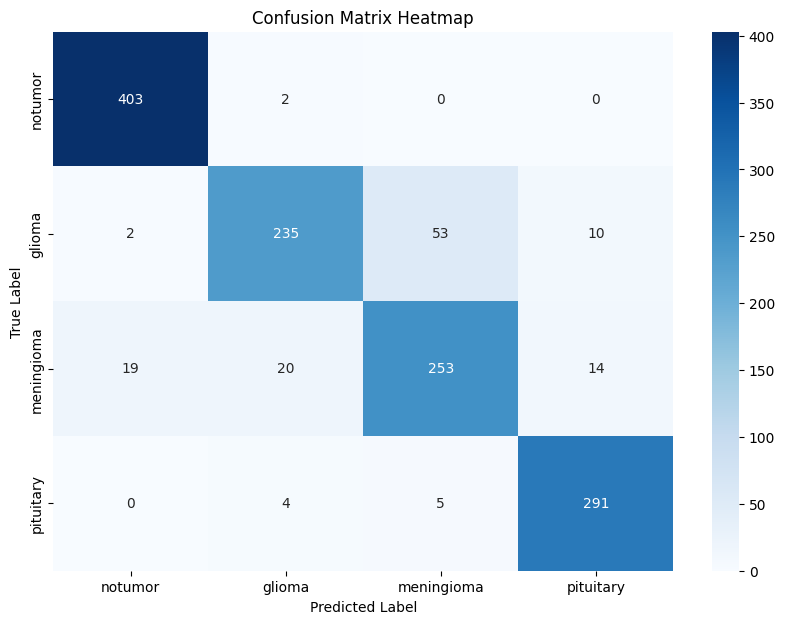

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
labeling = {
    'notumor': 0,
    'glioma': 1,
    'meningioma': 2,
    'pituitary': 3
}

con_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(con_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labeling, yticklabels=labeling)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Define the model
model = xgb.XGBClassifier(objective="mul:logistic", subsample=0.8,               
    colsample_bytree=0.8,        
    random_state=42, )

param_grid = {
    'n_estimators': [50,100, 150],
    'learning_rate': [0.01,0.1, 0.2],
    'max_depth': [3,5,7]
} 

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='accuracy', verbose=2, n_jobs=-1)

grid_search.fit(X_train, y_train)


print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 150}
Best cross-validation accuracy: 0.8291316526610645


In [23]:
best_model=grid_search.best_estimator_
best_model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, ...)

In [30]:
y_pred = best_model.predict(X_test) 
accuracy = accuracy_score(y_test, y_pred) 
print(f"Best Model Accuracy: {accuracy * 100:.2f}%") 

Best Model Accuracy: 92.75%


In [ ]:
print("\nClassification Report:") 
print(classification_report(y_test, y_pred))  


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       405
           1       0.93      0.82      0.87       300
           2       0.84      0.90      0.87       306
           3       0.93      0.97      0.95       300

    accuracy                           0.93      1311
   macro avg       0.92      0.92      0.92      1311
weighted avg       0.93      0.93      0.93      1311



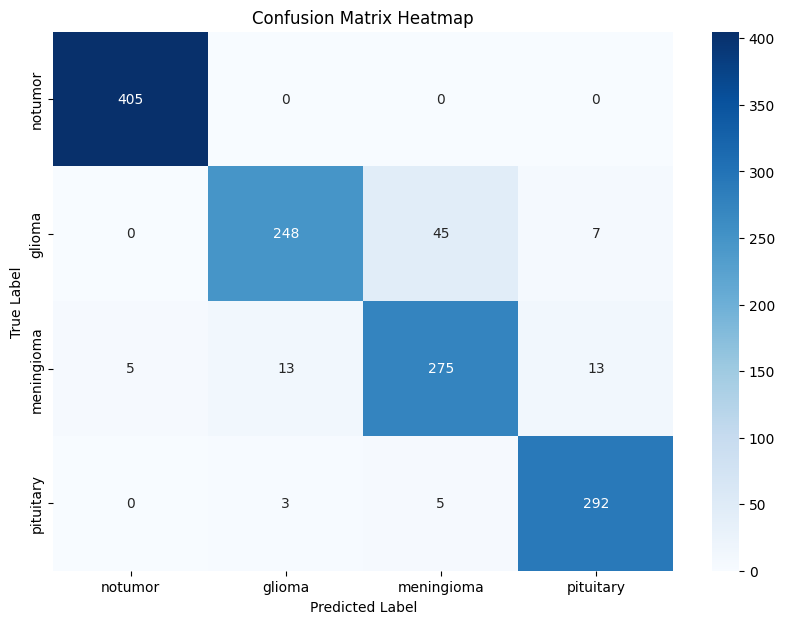

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
labeling = {
    'notumor': 0,
    'glioma': 1,
    'meningioma': 2,
    'pituitary': 3
}

con_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(con_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labeling, yticklabels=labeling)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [29]:

y_train_pred = best_model.predict(X_train)

# Evaluation
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("\nClassification Report:")
print(classification_report(y_train, y_train_pred))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1595
           1       1.00      1.00      1.00      1321
           2       1.00      1.00      1.00      1339
           3       1.00      1.00      1.00      1457

    accuracy                           1.00      5712
   macro avg       1.00      1.00      1.00      5712
weighted avg       1.00      1.00      1.00      5712



In [ ]:
from sklearn.model_selection import cross_val_score
train_score = cross_val_score(best_model, X_train, y_train, cv=5)
print(f"the training score of the model: {train_score}")


the training score of the model: [0.84864392 0.9343832  0.92556918 0.85288967 0.78633975]


In [12]:
print(sum(train_score)/5)

0.8695651441118022


In [ ]:
from sklearn.model_selection import cross_val_score
test_score = cross_val_score(best_model, X_test, y_test, cv=5)
print(f"the testing score of the model: {test_score}")


the training score of the model: [0.74524715 0.85114504 0.84351145 0.73282443 0.75572519]


In [13]:
print(sum(test_score)/5)

0.7856906510318404
